<a href="https://colab.research.google.com/github/spokenprim618/cmp-415/blob/main/Copy_of_HW_RandomForest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Random Forest Model for Churn Analysis

In this assignment, you will build a robust classification pipeline to predict customer churn. Please download the `Churn_Modelling.csv` dataset (available on [Kaggle](https://www.kaggle.com/datasets/shrutimechlearn/churn-modelling)). It contains features such as credit score, geography, gender, age, and tenure for bank customers, with a binary target Exited.

In [ ]:
import os
import gdown
import zipfile
import pandas as pd


# 1. Create data folder
os.makedirs("data", exist_ok=True)

# 2. Google Drive file ID (from your link)
file_id = "1BlJROCCeF-p6Kk7brev098tSPxyjDUp0"

# 3. Download path
zip_path = "data/file.zip"

# 4. Download the file
gdown.download(f"https://drive.google.com/uc?id={file_id}", zip_path, quiet=False)

# 5. Unzip it
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("data")

print("Done: Downloaded and extracted into /data")

Downloading...
From: https://drive.google.com/uc?id=1BlJROCCeF-p6Kk7brev098tSPxyjDUp0
To: /content/data/file.zip
100%|██████████| 268k/268k [00:00<00:00, 10.4MB/s]

Done: Downloaded and extracted into /data


In [ ]:
df = pd.read_csv('/content/data/Churn_Modelling.csv')
df_copy = df.copy()
df_copy.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


1. Feature Selection: Drop the `RowNumber`, `CustomerId`, and `Surname` columns.

In [ ]:
df_copy=df_copy.drop(columns=['RowNumber','CustomerId','Surname'])
print(df_copy['Geography'].unique())

['France' 'Spain' 'Germany']


2. Categorical Encoding: Use `pd.get_dummies()` with `drop_first=True` to transform the `Geography` column.

In [ ]:
df_copy=pd.get_dummies(df_copy,drop_first=True)


3. Split the dataset into a training set (75%) and a test set (25%).

In [ ]:
from sklearn.model_selection import train_test_split

train_set,test_set = train_test_split(df_copy,test_size=.25,random_state=42)

4. Baseline Model: Build a decision tree model with `max-depth=2`. Show the prediction accuracy and visualize the decision tree.

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

trainSet, testSet= train_test_split(
    df_copy,test_size=0.25, random_state=42
)
trainSet_output = trainSet['Exited']
trainSet=trainSet.drop(columns=['Exited'])

testSet_output = testSet['Exited']
testSet=testSet.drop(columns=['Exited'])


# Baseline model
model = DecisionTreeClassifier(max_depth=2, random_state=42)
model.fit(trainSet,trainSet_output)

DecisionTreeClassifier(max_depth=2, random_state=42)

5. Construct a `RandomForestClassifier` and use `GridSearchCV` to find the optimal configuration. The grid search should go over the following options:

    - max_depth: [2, 5, None]
    - min_samples_leaf: [1, 2, 5]
    - n_estimators: [50, 100, 200]

Perform a 5-fold cross-validation in the grid search to select the best values for these hyperparameters.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier(random_state=42)

param_grid = {
    'max_depth': [2, 5, None],
    'min_samples_leaf': [1, 2, 5],
    'n_estimators': [50, 100, 200]
}
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy'
)

grid_search.fit(trainSet,trainSet_output)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
             param_grid={'max_depth': [2, 5, None],
                         'min_samples_leaf': [1, 2, 5],
                         'n_estimators': [50, 100, 200]},
             scoring='accuracy')

6. (Optional for undergraduates) Training large ensembles can be time-consuming. Save your best-fit model to a file named `rf_model.pickle`, and demonstrate that you can retreive the model from the pickle file.

In [ ]:
best_model = grid_search.best_estimator_
import pickle

with open('data/rf_model.pickle', 'wb') as f:
    pickle.dump(best_model, f)

with open('data/rf_model.pickle', 'rb') as f:
    loaded_model = pickle.load(f)



7. Performance Metrics. Show the accuracy, precision, and recall of the best-fit model on the test set.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score
y_pred = loaded_model.predict(testSet)

accuracy = accuracy_score(testSet_output, y_pred)
precision = precision_score(testSet_output, y_pred)
recall = recall_score(testSet_output, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)

Accuracy: 0.8684
Precision: 0.7781456953642384
Recall: 0.47283702213279677


8. Analyze your model's performance: What are its strengths and weaknesses? Use metrics and error analysis to justify your conclusions.

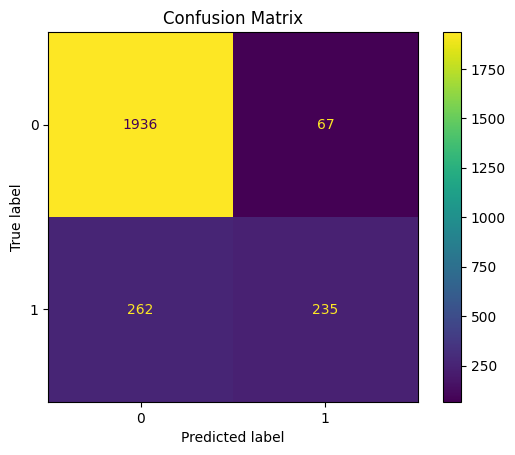

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(testSet_output, y_pred)

plt.title("Confusion Matrix")
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(testSet_output, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.97      0.92      2003
           1       0.78      0.47      0.59       497

    accuracy                           0.87      2500
   macro avg       0.83      0.72      0.75      2500
weighted avg       0.86      0.87      0.86      2500



From the classification report I can see non-churning has more data than churning. Both precision is high but non-churning is higher overall. The most telling metric is recall because it represents how many of the model positives were real and non-churning is almost perfect but churning is below half. This tells me the model is strong in detecting non-churning customers but not churned customers. Most likely this model needs high amounts of data to be accurate or the model is trained better for non-churning because of how much more data there is compared to churning. This can be supported through the confusion matrix due to the low amount of entries in churning while the majority is classified correctly, proportionally it would be a higher error than non-churning. This model is strong for the task but it fails to reliably detect churn, meaning it is biased toward predicting non-churn and misses most of actual churn cases.